# Exploratory Data Analysis — International Football Results
This notebook is for manual exploration only (no modeling). The goal is to
build intuition for the data before any feature engineering happens, so you
can sanity-check what the pipeline produces later against what you see here.

The notebook resolves data paths from the project root automatically so it
works from the repository root or from inside the notebooks folder.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

pd.set_option('display.max_columns', None)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'config' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root from the current working directory.')


repo_root = find_repo_root()
config = yaml.safe_load((repo_root / 'config' / 'config.yaml').read_text())
raw_dir = repo_root / Path(config['data_paths']['raw_results']).parent

results = pd.read_csv(raw_dir / 'results.csv', parse_dates=['date'])
goalscorers = pd.read_csv(raw_dir / 'goalscorers.csv', parse_dates=['date'])
shootouts = pd.read_csv(raw_dir / 'shootouts.csv', parse_dates=['date'])
former_names = pd.read_csv(raw_dir / 'former_names.csv', parse_dates=['start_date', 'end_date'])

print('Repository root:', repo_root)
print(results.shape, goalscorers.shape, shootouts.shape, former_names.shape)


Repository root: /home/moeen/projects/-Football-Match-Outcome-And-Score-Prediction
(49502, 9) (47867, 8) (681, 5) (36, 4)


## 1. results.csv — basic shape and quality

In [6]:
print("Date range:", results['date'].min(), "to", results['date'].max())
print("\nNulls:\n", results.isnull().sum())
print("\nRows with null scores (future/unplayed fixtures):")
results[results['home_score'].isnull() | results['away_score'].isnull()]

Date range: 1872-11-30 00:00:00 to 2026-07-09 00:00:00

Nulls:
 date          0
home_team     0
away_team     0
home_score    7
away_score    7
tournament    0
city          0
country       0
neutral       0
dtype: int64

Rows with null scores (future/unplayed fixtures):


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49495,2026-07-05,Brazil,Norway,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49496,2026-07-05,Mexico,England,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49497,2026-07-06,Portugal,Spain,NaN,NaN,FIFA World Cup,Dallas,United States,True
49498,2026-07-06,United States,Belgium,NaN,NaN,FIFA World Cup,Seattle,United States,False
49499,2026-07-06,Argentina,Egypt,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49500,2026-07-06,Switzerland,Colombia,NaN,NaN,FIFA World Cup,Vancouver,Canada,True
49501,2026-07-09,France,Morocco,NaN,NaN,FIFA World Cup,Foxborough,United States,True


In [7]:
# duplicate check on the key that matters for chronological processing
dupes = results[results.duplicated(subset=['date', 'home_team', 'away_team'], keep=False)]
print("Duplicate (date, home_team, away_team) rows:", len(dupes))
dupes.sort_values(['date','home_team']).head(10)

Duplicate (date, home_team, away_team) rows: 4


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
9641,1974-02-17,Tahiti,New Caledonia,2.0,1.0,Friendly,Papeete,Tahiti,False
9642,1974-02-17,Tahiti,New Caledonia,1.0,2.0,Friendly,Papeete,Tahiti,False
49352,2026-06-06,Gibraltar,Cayman Islands,4.0,1.0,Friendly,Gibraltar,Gibraltar,False
49361,2026-06-06,Gibraltar,Cayman Islands,4.0,1.0,Friendly,Europa Point,Gibraltar,False


## 2. Team and tournament coverage

In [8]:
all_teams = set(results['home_team']) | set(results['away_team'])
print("Unique team names:", len(all_teams))

tournament_counts = results['tournament'].value_counts()
print("\nNumber of distinct tournament labels:", len(tournament_counts))
tournament_counts.head(20)

Unique team names: 336

Number of distinct tournament labels: 200


tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1061
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

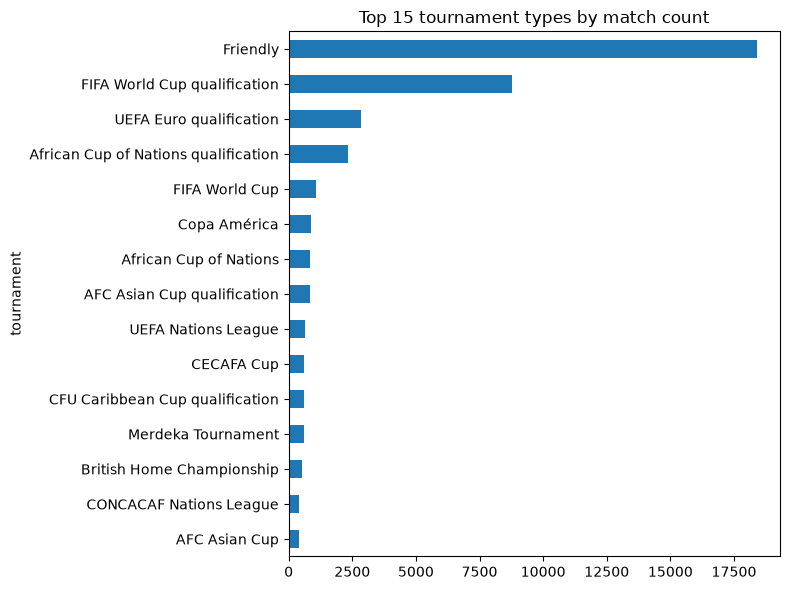

In [9]:
tournament_counts.head(15).plot(kind='barh', figsize=(8,6))
plt.title('Top 15 tournament types by match count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Home advantage — does home_team actually win more?

In [10]:
def outcome(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    return 'draw'

results_clean = results.dropna(subset=['home_score', 'away_score']).copy()
results_clean['neutral'] = results_clean['neutral'].fillna(False).astype(bool)
results_clean['outcome'] = results_clean.apply(outcome, axis=1)

print('Overall outcome distribution:')
print(results_clean['outcome'].value_counts(normalize=True))

print('\nOutcome distribution when NOT neutral venue:')
print(results_clean[results_clean['neutral'] == False]['outcome'].value_counts(normalize=True))

print('\nOutcome distribution when neutral venue (home advantage should shrink):')
print(results_clean[results_clean['neutral'] == True]['outcome'].value_counts(normalize=True))


Overall outcome distribution:
outcome
home_win    0.490070
away_win    0.282513
draw        0.227417
Name: proportion, dtype: float64

Outcome distribution when NOT neutral venue:
outcome
home_win    0.507481
away_win    0.263986
draw        0.228533
Name: proportion, dtype: float64

Outcome distribution when neutral venue (home advantage should shrink):
outcome
home_win    0.441882
away_win    0.333790
draw        0.224328
Name: proportion, dtype: float64


**What to look for:** home win rate should be noticeably higher than away win
rate in non-neutral matches, and that gap should shrink (though maybe not
vanish — "true neutral" is debatable, e.g. regional tournaments) in neutral
matches. If home advantage doesn't show up at all here, that's a red flag
worth understanding before you build Elo with a home_advantage constant.

## 4. Goals over time — has the game gotten higher or lower scoring?

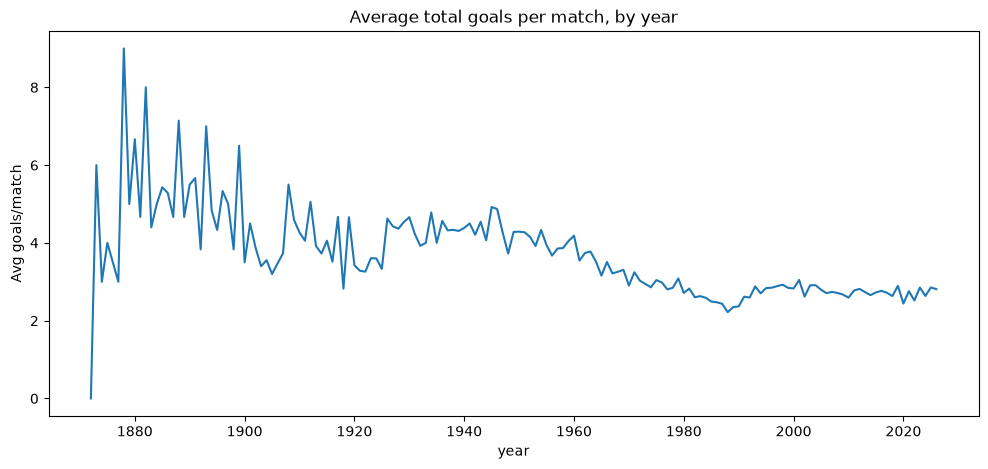

In [11]:
results_clean['year'] = results_clean['date'].dt.year
results_clean['total_goals'] = results_clean['home_score'] + results_clean['away_score']

avg_goals_per_year = results_clean.groupby('year')['total_goals'].mean()
avg_goals_per_year.plot(figsize=(12,5))
plt.title('Average total goals per match, by year')
plt.ylabel('Avg goals/match')
plt.show()

## 5. Draw rate over time — is 'draw' getting harder or easier to predict across eras?

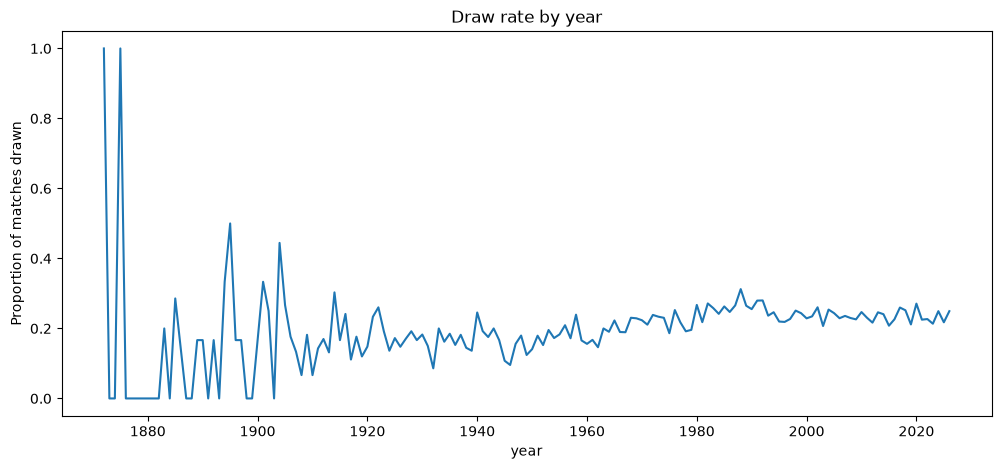

In [12]:
draw_rate_by_year = results_clean.groupby('year')['outcome'].apply(lambda x: (x=='draw').mean())
draw_rate_by_year.plot(figsize=(12,5))
plt.title('Draw rate by year')
plt.ylabel('Proportion of matches drawn')
plt.show()

## 6. Score margin distribution — sanity check for the Poisson assumption

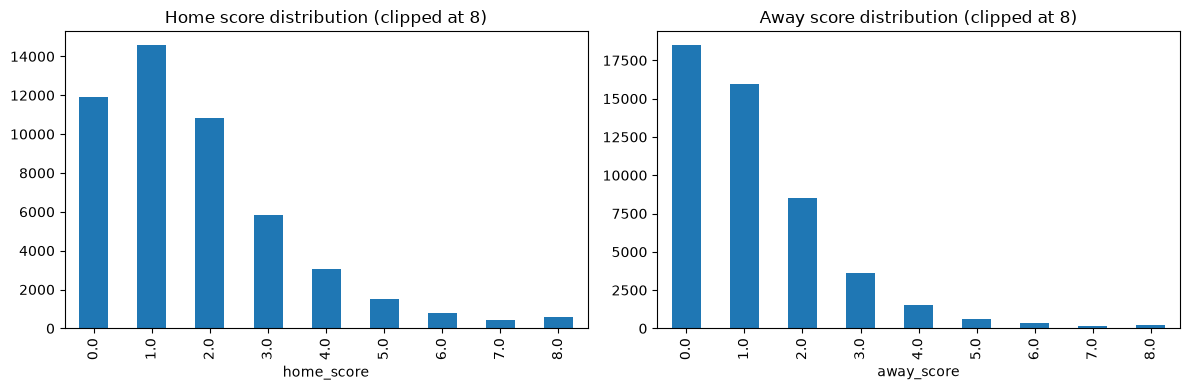

Home goals mean/var: 1.7572684109506012 3.14664045518973
Away goals mean/var: 1.1818365491463785 1.9645910829127287


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
results_clean['home_score'].clip(upper=8).value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Home score distribution (clipped at 8)')
results_clean['away_score'].clip(upper=8).value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Away score distribution (clipped at 8)')
plt.tight_layout()
plt.show()

print("Home goals mean/var:", results_clean['home_score'].mean(), results_clean['home_score'].var())
print("Away goals mean/var:", results_clean['away_score'].mean(), results_clean['away_score'].var())

**What to look for:** for a Poisson model to be a reasonable fit, mean and
variance of goals should be roughly similar (Poisson assumes mean = variance).
If variance is much higher than the mean, that's "overdispersion" and you may
need a Negative Binomial model instead down the line — worth knowing now,
not discovering after training.

## 7. goalscorers.csv — own goals and penalties

In [14]:
print("Own goal rate:", goalscorers['own_goal'].mean())
print("Penalty rate:", goalscorers['penalty'].mean())
print("\nNull scorer rows (data quality):", goalscorers['scorer'].isnull().sum())
print("Null minute rows:", goalscorers['minute'].isnull().sum())

Own goal rate: 0.01955418137756701
Penalty rate: 0.06812626653017737

Null scorer rows (data quality): 44
Null minute rows: 254


## 8. shootouts.csv — does shooting first actually help?

In [15]:
so = shootouts.dropna(subset=['first_shooter']).copy()
so['first_shooter_won'] = so['first_shooter'] == so['winner']
print("Shootouts with known first shooter:", len(so))
print("Win rate when shooting first:", so['first_shooter_won'].mean())

Shootouts with known first shooter: 259
Win rate when shooting first: 0.525096525096525


**What to look for:** this is a small sample (fewer than 681 rows, and many
missing `first_shooter`), so don't over-interpret a small edge either way —
this is a "curiosity check," not something to build a model on with
confidence.

## 9. former_names.csv — team identity changes

In [16]:
former_names.sort_values('start_date')

,current,former,start_date,end_date
22,Northern Ireland,Ireland,1882-02-18,1956-04-11
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
15,Guyana,British Guiana,1905-07-21,1967-08-02
31,Suriname,Dutch Guyana,1921-01-28,1975-11-25
23,Republic of Ireland,Irish Free State,1924-05-28,1936-12-06
25,Russia,Soviet Union,1924-11-16,1991-11-13
17,Israel,Mandatory Palestine,1934-03-16,1940-04-27
16,Indonesia,Dutch East Indies,1934-05-13,1951-03-04
24,Republic of Ireland,Éire,1937-01-01,1953-03-25
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


**What to look for:** confirm none of these former names still appear as
`home_team`/`away_team` values in `results.csv` — the dataset documentation
says current names are already used throughout, so this should come back
empty.

In [17]:
former_name_set = set(former_names['former'])
leaked_old_names = all_teams & former_name_set
print("Former names still appearing in results.csv (should be empty):", leaked_old_names)

Former names still appearing in results.csv (should be empty): set()


## 10. Match frequency over time — how has global participation grown?

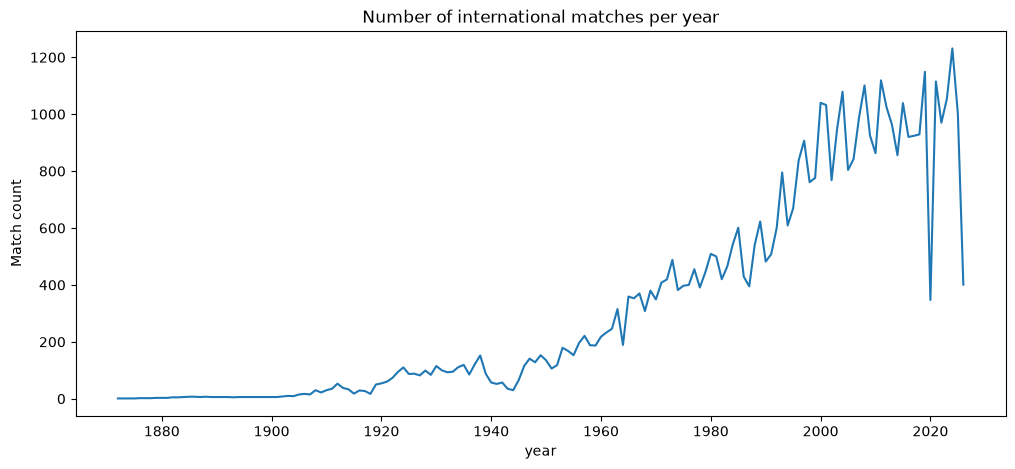

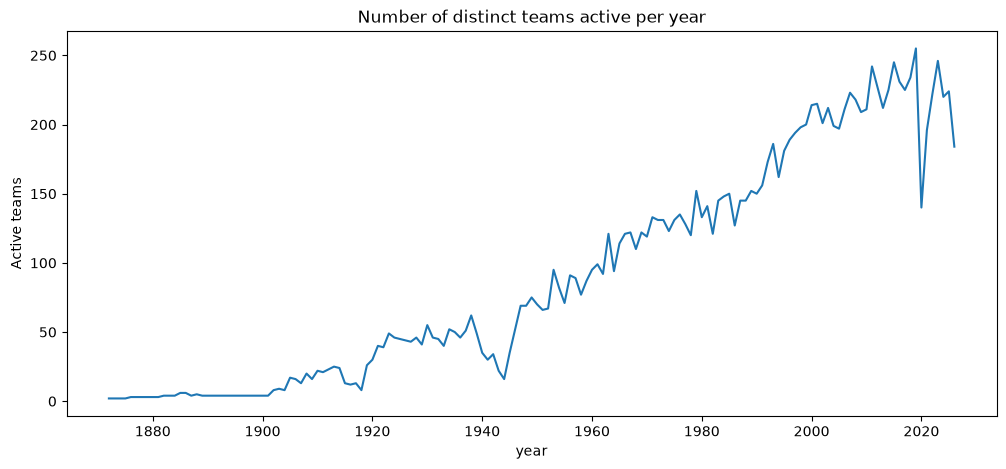

In [18]:
matches_per_year = results_clean.groupby('year').size()
matches_per_year.plot(figsize=(12,5))
plt.title('Number of international matches per year')
plt.ylabel('Match count')
plt.show()

teams_active_per_year = results_clean.groupby('year').apply(
    lambda d: len(set(d['home_team']) | set(d['away_team']))
)
teams_active_per_year.plot(figsize=(12,5))
plt.title('Number of distinct teams active per year')
plt.ylabel('Active teams')
plt.show()